# Module C: Magnetometer

### C.1 Load in the data collected:

In [5]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec


path = '4_13_26\C2.HardSoftIron.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 617 samples


### C.2 Plot the raw data 

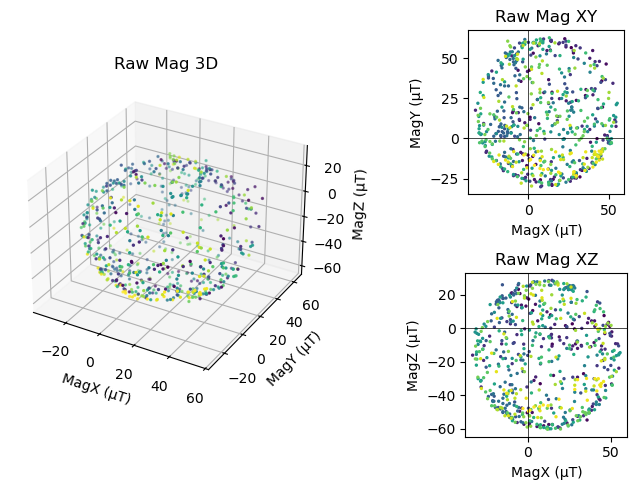

In [6]:
fig = plt.figure(figsize=(8, 5))  # slightly wider overall
gs = GridSpec(2, 2, width_ratios=[1, 1.5])  # RIGHT side wider

# --- Left: 3D plot ---
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')

# --- Top-right: XY ---
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx, my, s=2, c=t, cmap='viridis')
ax_xy.set_aspect('equal')
ax_xy.set_title('Raw Mag XY')
ax_xy.set_xlabel('MagX (µT)')
ax_xy.set_ylabel('MagY (µT)')
ax_xy.axhline(0, color='k', lw=0.5)
ax_xy.axvline(0, color='k', lw=0.5)

# --- Bottom-right: XZ ---
ax_xz = fig.add_subplot(gs[1, 1])
ax_xz.scatter(mx, mz, s=2, c=t, cmap='viridis')
ax_xz.set_aspect('equal')
ax_xz.set_title('Raw Mag XZ')
ax_xz.set_xlabel('MagX (µT)')
ax_xz.set_ylabel('MagZ (µT)')
ax_xz.axhline(0, color='k', lw=0.5)
ax_xz.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

### C.3 Compute the Hard offsets

In [7]:
mx_min = min(mx)
mx_max = max(mx)
my_min = min(my)
my_max = max(my)
mz_min = min(mz)
mz_max = max(mz)

offset_x = (mx_max + mx_min) / 2
offset_y = (my_max + my_min) / 2
offset_z = (mz_max + mz_min) / 2

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')
print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

MagX range: -33.00 to 55.35 µT
MagY range: -30.15 to 62.70 µT
MagZ range: -60.45 to 28.80 µT
Hard iron offsets: X=11.175, Y=16.275, Z=-15.825 µT


### C.4 Calibrate with the Hard Offsets solved for and plot it:

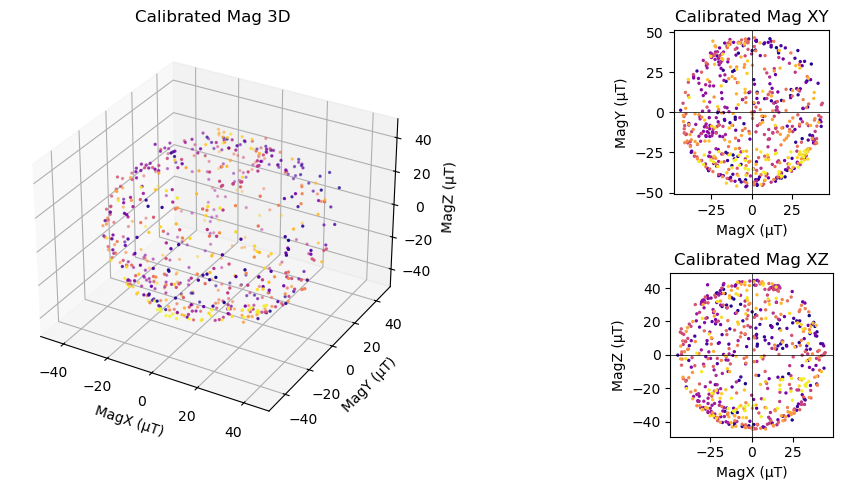

In [8]:
mx_cal = [x - offset_x for x in mx]
my_cal = [y - offset_y for y in my]
mz_cal = [z - offset_z for z in mz]

# --- Figure layout ---
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 2, width_ratios=[1, 1.5])  # right side wider

# --- Left: 3D plot ---
ax3d = fig.add_subplot(gs[:, 0], projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')

# --- Top-right: XY ---
ax_xy = fig.add_subplot(gs[0, 1])
ax_xy.scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
ax_xy.set_aspect('equal')
ax_xy.set_title('Calibrated Mag XY')
ax_xy.set_xlabel('MagX (µT)')
ax_xy.set_ylabel('MagY (µT)')
ax_xy.axhline(0, color='k', lw=0.5)
ax_xy.axvline(0, color='k', lw=0.5)

# --- Bottom-right: XZ ---
ax_xz = fig.add_subplot(gs[1, 1])
ax_xz.scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
ax_xz.set_aspect('equal')
ax_xz.set_title('Calibrated Mag XZ')
ax_xz.set_xlabel('MagX (µT)')
ax_xz.set_ylabel('MagZ (µT)')
ax_xz.axhline(0, color='k', lw=0.5)
ax_xz.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Writeup 

Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |   11.175    |
| Y    |   16.275    |
| Z    |  -15.825    |

**Discussion questions:**
1. Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?
    1A. After calibration, the 3D scatter plot looks like an elongated sphere. This is due to the offsets simply translating the sphere to the origin but does not account for scaling or distortion so each axis could be slightly more sensitive than others. As shown in the plot, the Magnitude range differs per axis further validating a soft-iron correction could be necessary. 
    
2. How complete is your coverage of orientations? Are there gaps in the scatter plot?
    **unfinished**
    
3. What happens to your heading estimate if you skip calibration?

    **unfinished**